In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from mplsoccer import PyPizza

In [2]:
df = pd.read_csv(r"C:\Projects\Tisini\Visualization\Leagues Tornaments Friendlies\Equity\Men\Equity FC 2025-26 Player Analysis with Per 90.csv")

In [3]:
df.columns

Index(['Player', 'Position', 'Passes Complete', 'Passes Incomplete',
       'Pass Accuracy %', 'Goals', 'Assists', 'Shots (in+out box)',
       'Fouls Committed', 'Yellow Cards', 'Red Cards', 'Tackles Won',
       'Tackles Lost', 'Total Tackles', 'Tackle Success Rate %',
       'Tackles Won /90', 'Tackles Lost /90', 'Interceptions',
       'Interceptions /90', 'Crosses Attempted', 'Crosses Complete',
       'Cross Accuracy %', 'Crosses Attempted /90', 'Crosses Complete /90',
       'Ball Won Opp', 'Ball Won Own', 'Ball Own Lost', 'Ball Opp Lost',
       'Dribbles', 'Box Carry', 'Box Touch', 'Progressive Passes Complete',
       'Progressive Passes Incomplete', 'Estimated Minutes', 'Matches',
       'Estimated Starts', 'Estimated Sub Apps', 'Estimated 90s',
       'Passes Complete /90', 'Passes Incomplete /90', 'Goals /90',
       'Assists /90', 'Shots (in+out box) /90', 'Fouls Committed /90',
       'Ball Won Opp /90', 'Ball Won Own /90', 'Ball Own Lost /90',
       'Ball Opp Lost /90'

In [10]:
# --------------------------------
# Minimum minutes
# --------------------------------

MIN_MINUTES = 400

# --------------------------------
# Pizza metric groups
# --------------------------------

attacking_metrics = {
    "Goals /90": "Goals /90",
    "Assists /90": "Assists /90",
    "Shots /90": "Shots (in+out box) /90",
}

defending_metrics = {
    "Tackles Won /90": "Tackles Won /90",
    "Tackles Lost /90": "Tackles Lost /90",
    "Interceptions /90": "Interceptions /90",
    "Ball Won Own /90": "Ball Won Own /90",
    "Ball Won Opp /90": "Ball Won Opp /90",
    "Ball Own Lost /90": "Ball Own Lost /90",
    "Ball Opp Lost /90": "Ball Opp Lost /90",
}

possession_metrics = {
    "Passes Complete /90": "Passes Complete /90",
    "Passes Incomplete /90": "Passes Incomplete /90",
    "Dribbles /90": "Dribbles /90",
    "Box Carry /90": "Box Carry /90",
    "Box Touch /90": "Box Touch /90",
    "Progressive Passes /90": "Progressive Passes Complete /90",
    "Crosses Complete /90": "Crosses Complete /90",
}

# --------------------------------
# Columns required for pizza
# --------------------------------

pizza_columns = (
    ["Player", "Position", "Estimated Minutes", "Estimated 90s"]
    + list(attacking_metrics.values())
    + list(defending_metrics.values())
    + list(possession_metrics.values())
)

pizza_df = df[pizza_columns].copy()

# --------------------------------
# Convert minutes to integer
# --------------------------------

pizza_df["Estimated Minutes"] = (
    pizza_df["Estimated Minutes"]
    .round()
    #.astype(int)
)

# --------------------------------
# Minimum minutes filter
# --------------------------------

pizza_df = pizza_df[
    pizza_df["Estimated Minutes"] >= MIN_MINUTES
].copy()

pizza_df.head()

,Player,Position,Estimated Minutes,Estimated 90s,Goals /90,Assists /90,Shots (in+out box) /90,Tackles Won /90,Tackles Lost /90,Interceptions /90,...,Ball Won Opp /90,Ball Own Lost /90,Ball Opp Lost /90,Passes Complete /90,Passes Incomplete /90,Dribbles /90,Box Carry /90,Box Touch /90,Progressive Passes Complete /90,Crosses Complete /90
0,Abdi Abdi,Fullback,1378.0,15.31,0.07,0.00,1.11,0.00,0.07,2.87,...,0.26,0.59,1.18,20.63,3.07,0.26,0.13,1.04,0.52,0.52
1,Barrack Dago,Centre Back,1387.0,15.41,0.06,0.06,0.58,0.26,0.06,4.61,...,0.06,0.19,0.00,26.79,3.05,0.00,0.00,0.00,0.19,0.00
2,Bernard Lusi,Centre Back,3087.0,34.30,0.15,0.03,1.02,0.44,0.15,3.99,...,0.09,0.58,0.52,32.68,4.40,0.15,0.00,1.37,0.70,0.17
3,Bevex David,Winger,1801.0,20.01,0.35,0.10,1.70,0.05,0.05,0.80,...,0.65,0.85,3.75,12.29,2.40,1.35,0.55,2.55,0.10,0.20
8,Elvis Odhiambo,Midfielder,1383.0,15.37,0.00,0.07,0.39,0.00,0.00,3.64,...,0.59,0.85,0.65,27.39,3.32,0.26,0.26,1.04,0.46,0.07


In [11]:
# --------------------------------
# Percentile calculations
# --------------------------------

# Metrics where lower values are better
lower_is_better = {
    "Tackles Lost /90",
    "Ball Own Lost /90",
    "Ball Opp Lost /90",
    "Passes Incomplete /90",
}

# Combine all metric groups
metric_groups = {
    **attacking_metrics,
    **defending_metrics,
    **possession_metrics,
}

# Calculate percentiles
for label, column in metric_groups.items():

    percentile = pizza_df[column].rank(pct=True) * 100

    if label in lower_is_better:
        percentile = 100 - percentile

    pizza_df[f"{label} Percentile"] = percentile.round()

# Keep percentile columns as nullable integers
percentile_columns = [col for col in pizza_df.columns if col.endswith("Percentile")]

pizza_df[percentile_columns] = (pizza_df[percentile_columns].astype("Int64"))

pizza_df.head()

,Player,Position,Estimated Minutes,Estimated 90s,Goals /90,Assists /90,Shots (in+out box) /90,Tackles Won /90,Tackles Lost /90,Interceptions /90,...,Ball Won Opp /90 Percentile,Ball Own Lost /90 Percentile,Ball Opp Lost /90 Percentile,Passes Complete /90 Percentile,Passes Incomplete /90 Percentile,Dribbles /90 Percentile,Box Carry /90 Percentile,Box Touch /90 Percentile,Progressive Passes /90 Percentile,Crosses Complete /90 Percentile
0,Abdi Abdi,Fullback,1378.0,15.31,0.07,0.00,1.11,0.00,0.07,2.87,...,47,56,35,41,53,68,71,62,65,82
1,Barrack Dago,Centre Back,1387.0,15.41,0.06,0.06,0.58,0.26,0.06,4.61,...,18,88,91,71,59,18,26,18,29,15
2,Bernard Lusi,Centre Back,3087.0,34.30,0.15,0.03,1.02,0.44,0.15,3.99,...,24,65,76,94,12,47,26,71,76,41
3,Bevex David,Winger,1801.0,20.01,0.35,0.10,1.70,0.05,0.05,0.80,...,88,21,6,18,82,88,88,88,24,47
8,Elvis Odhiambo,Midfielder,1383.0,15.37,0.00,0.07,0.39,0.00,0.00,3.64,...,76,21,71,76,47,68,76,62,56,29


In [12]:
print(len(pizza_df["Player"].tolist()))
print(pizza_df["Player"].tolist())

17
['Abdi Abdi', 'Barrack Dago', 'Bernard Lusi', 'Bevex David', 'Elvis Odhiambo', 'Frederick Iyanza', 'George Kamau', 'Isaac Owiyo', 'Mainge Muthoka', 'Michael Onyango', 'Rashid Moyo', 'Robert Mutua', 'Samuel Ochieng', 'Song Wingston', 'Sydney Ogutu', 'Wayne Mureithi', 'Vinedine Ambetsa']


This cell will:

Choose the player.
Pull their position and minutes.
Collect the percentile scores.
Keep the order Attacking → Defending → Possession.
Create the parameter labels that PyPizza will display.

In [13]:
# --------------------------------
# Select player
# --------------------------------

player_name = "Robert Mutua"

player_data = pizza_df[pizza_df["Player"] == player_name].iloc[0]

# Player information
player_position = player_data["Position"]
player_minutes = int(round(player_data["Estimated Minutes"]))

# --------------------------------
# Pizza parameters
# --------------------------------

attacking_params = list(attacking_metrics.keys())
defending_params = list(defending_metrics.keys())
possession_params = list(possession_metrics.keys())

params = (
    attacking_params
    + defending_params
    + possession_params
)

# --------------------------------
# Player percentile values
# --------------------------------

values = [int(player_data[f"{metric} Percentile"]) for metric in params]

print("Player:", player_name)
print("Position:", player_position)
print("Minutes:", player_minutes)
print("Parameters:", params)
print("Values:", values)

Player: Robert Mutua
Position: Midfielder
Minutes: 1602
Parameters: ['Goals /90', 'Assists /90', 'Shots /90', 'Tackles Won /90', 'Tackles Lost /90', 'Interceptions /90', 'Ball Won Own /90', 'Ball Won Opp /90', 'Ball Own Lost /90', 'Ball Opp Lost /90', 'Passes Complete /90', 'Passes Incomplete /90', 'Dribbles /90', 'Box Carry /90', 'Box Touch /90', 'Progressive Passes /90', 'Crosses Complete /90']
Values: [79, 94, 53, 59, 38, 35, 38, 71, 0, 41, 88, 35, 18, 53, 53, 71, 65]


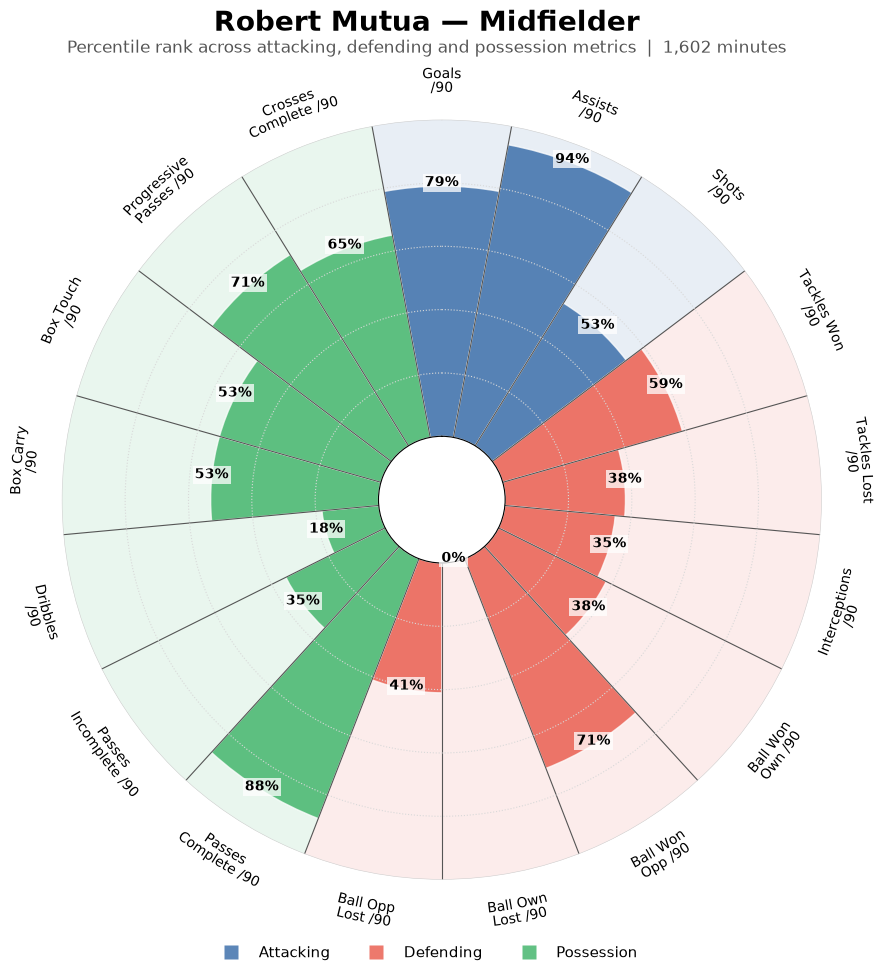

In [16]:
# --------------------------------
# Create Pizza
# --------------------------------

# Colors for each section
attacking_color = "#255EA0"   # Blue
defending_color = "#E74C3C"   # Red
possession_color = "#2EAD5B"   # Green

slice_colors = (
    [attacking_color] * len(attacking_params)
    + [defending_color] * len(defending_params)
    + [possession_color] * len(possession_params)
)

# --------------------------------
# Stack metric labels
# --------------------------------

def stack_label(label):
    replacements = {
        "Goals /90": "Goals\n/90",
        "Assists /90": "Assists\n/90",
        "Shots /90": "Shots\n/90",

        "Tackles Won /90": "Tackles Won\n/90",
        "Tackles Lost /90": "Tackles Lost\n/90",
        "Interceptions /90": "Interceptions\n/90",

        "Ball Won Own /90": "Ball Won\nOwn /90",
        "Ball Won Opp /90": "Ball Won\nOpp /90",
        "Ball Own Lost /90": "Ball Own\nLost /90",
        "Ball Opp Lost /90": "Ball Opp\nLost /90",

        "Passes Complete /90": "Passes\nComplete /90",
        "Passes Incomplete /90": "Passes\nIncomplete /90",
        "Dribbles /90": "Dribbles\n/90",
        "Box Carry /90": "Box Carry\n/90",
        "Box Touch /90": "Box Touch\n/90",
        "Progressive Passes /90": "Progressive\nPasses /90",
        "Crosses Complete /90": "Crosses\nComplete /90",
    }

    return replacements.get(label, label)

display_params = [stack_label(param) for param in params]

# --------------------------------
# Pizza setup
# --------------------------------

pizza = PyPizza(
    params=display_params,

    background_color="white",

    # Straight lines between slices
    straight_line_color="#555555",
    straight_line_lw=0.8,

    # Outer 100 circle
    last_circle_color="#D0D0D0",
    last_circle_lw=0.8,

    # Inner percentile circles
    other_circle_color="#D9D9D9",
    other_circle_lw=0.8,
    other_circle_ls=":",

    inner_circle_size=20,
)

# --------------------------------
# Draw Pizza
# --------------------------------

fig, ax = pizza.make_pizza(
    values,

    figsize=(12, 10),

    # Color to fill blank space
    color_blank_space='same',
    blank_alpha=0.1,

    # Position of metric labels
    param_location=110,

    # --------------------------------
    # Slice appearance
    # --------------------------------

    kwargs_slices=dict(
        facecolor=slice_colors,
        edgecolor="white",
        linewidth=1,
        alpha=0.75,
    ),

    # --------------------------------
    # Metric labels
    # --------------------------------

    curved_params=True,

    kwargs_params=dict(
        fontsize=10,
        color="black",
        va="center",
        # ha="center",
        linespacing=1.0,
    ),

    # --------------------------------
    # Percentage values
    # --------------------------------

    kwargs_values=dict(
        fontsize=10,
        color="black",
        zorder=5,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5,
        ),
    ),
)

# --------------------------------
# Add % to percentile values
# --------------------------------

value_texts = pizza.get_value_texts()

for text, value in zip(value_texts, values):
    text.set_text(f"{value}%")

# --------------------------------
# Title
# --------------------------------

fig.text(
    0.50,
    0.98,
    f"{player_name} — {player_position}",
    fontsize=20,
    fontweight="bold",
    ha="center",
    va="top",
    color="black",
)

# Subtitle
fig.text(
    0.50,
    0.95,
    f"Percentile rank across attacking, defending and possession metrics"
    f"  |  {player_minutes:,} minutes",
    fontsize=12,
    ha="center",
    va="top",
    color="#555555",
)

# --------------------------------
# Legend
# --------------------------------

legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markersize=10,
        markerfacecolor=attacking_color,
        markeredgecolor="none",
        alpha=0.75,
        label="Attacking",
    ),

    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markersize=10,
        markerfacecolor=defending_color,
        markeredgecolor="none",
        alpha=0.75,
        label="Defending",
    ),

    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markersize=10,
        markerfacecolor=possession_color,
        markeredgecolor="none",
        alpha=0.75,
        label="Possession",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.50, 0.015),
    ncol=3,
    frameon=False,
    fontsize=11,
)

# Leave room for title and legend
plt.subplots_adjust(
    top=0.87,
    bottom=0.11,
)

plt.show()